In [1]:
import torch
import torch.nn as nn
import esm
import csv
from datetime import datetime
import os
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch.utils.data import DataLoader, Dataset
import pandas as pd
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
timestamp = datetime.now().strftime('%d-%b_%H-%M-%S')

In [2]:
class ESM2_TransformerHead(nn.Module):
    def __init__(self, num_layers=2, nhead=8, hidden_dim=256, dropout=0.3):
        super().__init__()

        self.esm, self.alphabet = esm.pretrained.esm2_t33_650M_UR50D()
        self.batch_converter = self.alphabet.get_batch_converter()
        self.esm.eval()

        for param in self.esm.parameters():
            param.requires_grad = False
        for param in self.esm.layers[-10:].parameters():
            param.requires_grad = True

        encoder_layer = TransformerEncoderLayer(d_model=self.esm.embed_dim, nhead=nhead, dim_feedforward=hidden_dim, dropout=dropout)
        self.transformer = TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(self.esm.embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2)
        )

    def forward(self, seqs): 
        batch_labels = [("seq", s) for s in seqs]
        _, _, tokens = self.batch_converter(batch_labels)
        tokens = tokens.to(next(self.parameters()).device) 

        with torch.no_grad():
            rep = self.esm(tokens, repr_layers=[12])["representations"][12]
        rep = rep.permute(1, 0, 2)
        encoded = self.transformer(rep) 
        pooled = encoded[0]


        return self.classifier(pooled)


In [3]:
class MutationDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

    def __len__(self):
        return len(self.sequences)


In [4]:
df = pd.read_csv("datasets/mutation_30mer_dataset153.csv")
patho_df = df[df["Label"] == 1]
benign_df = df[df["Label"] == 0]

min_count = min(len(patho_df), len(benign_df))

pathogenic_balanced = resample(patho_df, replace=False, n_samples=min_count, random_state=13)
benign_balanced = resample(benign_df, replace=False, n_samples=min_count, random_state=13)

balanced_df = pd.concat([pathogenic_balanced, benign_balanced]).sample(frac=1, random_state=13) 

In [5]:
def collate_fn_stringbatch(batch):
    sequences, labels = zip(*batch)
    return list(sequences), torch.tensor(labels)


In [6]:
X = balanced_df["Mut_30mer"].values
y = balanced_df["Label"].values

xtrain, xtest, ytrain, ytest= train_test_split(X, y, test_size=0.15, stratify=y)

training_data = MutationDataset(xtrain, ytrain)
test_data = MutationDataset(xtest, ytest)
 
train_loader = DataLoader(training_data, batch_size=32, shuffle=True, collate_fn=collate_fn_stringbatch)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, collate_fn=collate_fn_stringbatch)


In [7]:
model = ESM2_TransformerHead(nhead=1, num_layers=1, hidden_dim=256).to(device)

c:\Users\brian\Documents\! Grad School\Classes\CSE 566\Mutation-Prediction\venv\Lib\site-packages\torch\nn\modules\transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [8]:
model

ESM2_TransformerHead(
  (esm): ESM2(
    (embed_tokens): Embedding(33, 1280, padding_idx=1)
    (layers): ModuleList(
      (0-32): 33 x TransformerLayer(
        (self_attn): MultiheadAttention(
          (k_proj): Linear(in_features=1280, out_features=1280, bias=True)
          (v_proj): Linear(in_features=1280, out_features=1280, bias=True)
          (q_proj): Linear(in_features=1280, out_features=1280, bias=True)
          (out_proj): Linear(in_features=1280, out_features=1280, bias=True)
          (rot_emb): RotaryEmbedding()
        )
        (self_attn_layer_norm): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (fc1): Linear(in_features=1280, out_features=5120, bias=True)
        (fc2): Linear(in_features=5120, out_features=1280, bias=True)
        (final_layer_norm): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      )
    )
    (contact_head): ContactPredictionHead(
      (regression): Linear(in_features=660, out_features=1, bias=True)
      (activati

In [9]:
model.load_state_dict(torch.load(os.path.join('ignore', "pt_files", "best_esm_model211.pt")))

<All keys matched successfully>

In [10]:
patience = 5
best_val_acc = float('inf')
epochs_no_improve = 0
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
optimizer = torch.optim.SGD(model.parameters(), lr=0.0005, weight_decay=0.0005)
criterion = nn.CrossEntropyLoss()
csv_log_path = f"/custom_esm/metrics_cesm_{timestamp}.csv"

metrics_log = []
train_losses, val_losses = [], []
epochs = 45
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

for ep in range(1, epochs + 1):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    print(f"Epoch {ep}: \tTrain Loss = {train_loss:.4f}, Train Accuracy = {train_acc:.4f}")
    
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_loss = test_loss / len(test_loader)
    val_losses.append(val_loss)
    metrics_log.append({
    "epoch": ep,
    "train_loss": train_loss,
    "train_acc": train_acc,
    "val_loss": val_loss,
    "val_acc": val_acc
    })
    scheduler.step(val_loss)
    print(f"\t \t Test Loss = {val_loss:.4f},  Test Accuracy = {val_acc:.4f}\n")
    if val_acc < best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), os.path.join('ignore', "pt_files", "best_esm_model897.pt"))
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"e-stop")
        break


c:\Users\brian\Documents\! Grad School\Classes\CSE 566\Mutation-Prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\brian\Documents\! Grad School\Classes\CSE 566\Mutation-Prediction\venv\Lib\site-packages\torch\nn\functional.py:5476: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


Epoch 1: 	Train Loss = 0.4410, Train Accuracy = 0.7966
	 	 Test Loss = 0.3951,  Test Accuracy = 0.8499

Epoch 2: 	Train Loss = 0.4337, Train Accuracy = 0.7970
	 	 Test Loss = 0.3962,  Test Accuracy = 0.8499

Epoch 3: 	Train Loss = 0.4370, Train Accuracy = 0.7943
	 	 Test Loss = 0.4009,  Test Accuracy = 0.8397

Epoch 4: 	Train Loss = 0.4343, Train Accuracy = 0.7867
	 	 Test Loss = 0.3992,  Test Accuracy = 0.8448

Epoch 5: 	Train Loss = 0.4325, Train Accuracy = 0.8015
	 	 Test Loss = 0.3984,  Test Accuracy = 0.8524

Epoch 6: 	Train Loss = 0.4218, Train Accuracy = 0.8078
	 	 Test Loss = 0.3975,  Test Accuracy = 0.8524

Epoch 7: 	Train Loss = 0.4223, Train Accuracy = 0.8024
	 	 Test Loss = 0.3984,  Test Accuracy = 0.8499

Epoch 8: 	Train Loss = 0.4115, Train Accuracy = 0.8137
	 	 Test Loss = 0.3980,  Test Accuracy = 0.8422

e-stop


In [18]:
folder = "custom_esm"
os.makedirs(folder, exist_ok=True)

# Create CSV filename inside the folder
csv_log_path = os.path.join(folder, f"metrics_cems_{timestamp}.csv")

# Now write the file
with open(csv_log_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["epoch", "train_loss", "train_acc", "val_loss", "val_acc"])
    writer.writeheader()
    writer.writerows(metrics_log)

print(f"CSV saved to {csv_log_path}")

CSV saved to custom_esm\metrics_cems_20250503_010555.csv


In [19]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        labels = labels.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

In [20]:
print("📋 Final Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["benign", "pathogenic"]))


📋 Final Classification Report:

              precision    recall  f1-score   support

      benign       0.85      0.84      0.84       196
  pathogenic       0.84      0.85      0.84       197

    accuracy                           0.84       393
   macro avg       0.84      0.84      0.84       393
weighted avg       0.84      0.84      0.84       393



Evaluation Metrics:
 {'Accuracy': 0.8422391857506362, 'Precision': 0.8391959798994975, 'Recall': 0.8477157360406091, 'F1 Score': 0.8434343434343434}


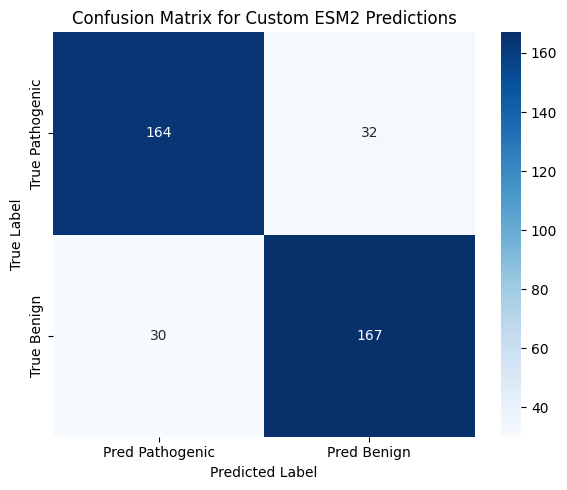

In [21]:
# Metrics dictionary
metrics = {
    'Accuracy': accuracy_score(all_labels, all_preds),
    'Precision': precision_score(all_labels, all_preds),
    'Recall': recall_score(all_labels, all_preds),
    'F1 Score': f1_score(all_labels, all_preds),
}
print("Evaluation Metrics:\n", metrics)
conf_mat = confusion_matrix(all_labels, all_preds)
report = classification_report(all_labels, all_preds, labels=[1, 0], target_names=["pathogenic", "benign"], output_dict=True)

conf_df = pd.DataFrame(conf_mat, index=["True Pathogenic", "True Benign"],
                       columns=["Pred Pathogenic", "Pred Benign"])
plt.figure(figsize=(6, 5))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Custom ESM2 Predictions")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

C:\Users\brian\AppData\Local\Temp\ipykernel_8428\1927221209.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=metrics_df.index, x=metrics_df["Value"], palette="coolwarm")


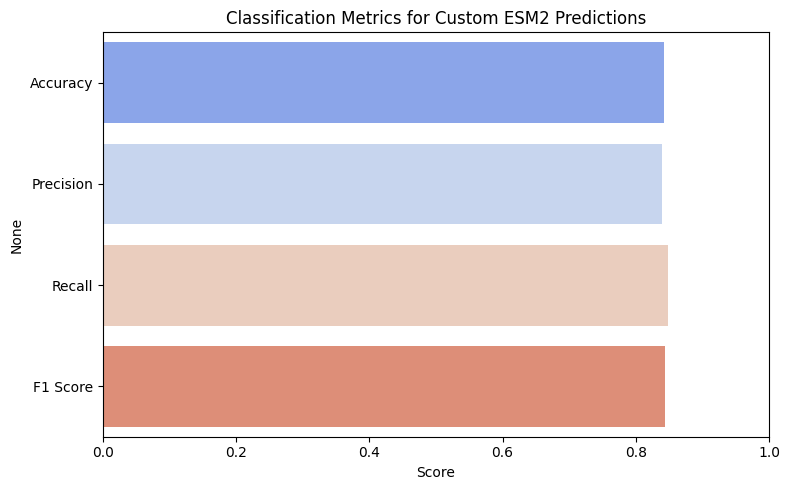

In [22]:
metrics_df = pd.DataFrame.from_dict(metrics, orient="index", columns=["Value"])
plt.figure(figsize=(8, 5))
sns.barplot(y=metrics_df.index, x=metrics_df["Value"], palette="coolwarm")
plt.title("Classification Metrics for Custom ESM2 Predictions")
plt.xlabel("Score")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

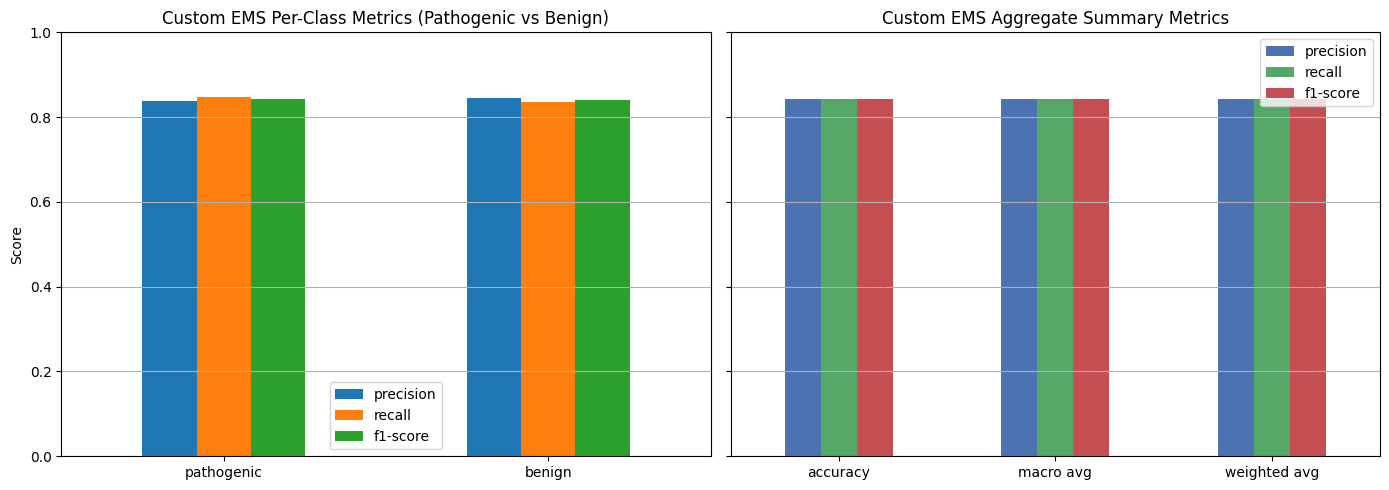

In [23]:
report_df = pd.DataFrame(report).transpose()

class_metrics = report_df.loc[['pathogenic', 'benign']]
summary_metrics = report_df.loc[['accuracy', 'macro avg', 'weighted avg']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

class_metrics[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=axes[0])
axes[0].set_title("Custom EMS Per-Class Metrics (Pathogenic vs Benign)")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].grid(True, axis='y')
axes[0].set_xticklabels(class_metrics.index, rotation=0)

summary_metrics[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=axes[1], color=['#4c72b0', '#55a868', '#c44e52'])
axes[1].set_title("Custom EMS Aggregate Summary Metrics")
axes[1].set_ylim(0, 1)
axes[1].grid(True, axis='y')
axes[1].set_xticklabels(summary_metrics.index, rotation=0)

plt.tight_layout()
plt.show()

In [24]:
print("\nFull Classification Report:")
print(pd.DataFrame(report).transpose())


Full Classification Report:
              precision    recall  f1-score     support
pathogenic     0.839196  0.847716  0.843434  197.000000
benign         0.845361  0.836735  0.841026  196.000000
accuracy       0.842239  0.842239  0.842239    0.842239
macro avg      0.842278  0.842225  0.842230  393.000000
weighted avg   0.842271  0.842239  0.842233  393.000000
